In [1]:
import os

import scipy as sc
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [8]:
INPUT_DIR = "/Users/willtrim/Desktop/RNAseq Bed Rest Data/"

work_dir = os.path.join(INPUT_DIR, "workdir")
# counts = pd.read_csv(counts_fp)

# Data load

In [14]:
import decoupler as dc

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62456,p53,ENPP2,2.771405,4.993215e-02
62457,p53,ARRDC4,3.494328,4.996747e-02
62458,p53,MYO1B,-1.148057,4.997905e-02
62459,p53,CTSC,-1.784693,4.998864e-02


In [16]:
collectri = dc.op.collectri(organism="human")

In [17]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [18]:
signor = dc.op.resource("SIGNOR")
signor = signor[~signor.duplicated(("genesymbol", "pathway"))]
signor = signor.rename(columns={'pathway' : 'source', 'genesymbol': 'target'})
signor

,genesymbol,pathway
,,
0,ABL1,Cell cycle: G2/M phase transition
1,ACE,Focal segmental glomerulosclerosis
2,ACTB,Axon guidance
3,ACTN1,Axon guidance
4,ACTN1,Glutamatergic synapse
...,...,...
2943,YY1,NOTCH Signaling
2944,ZAP70,T cell activation
2945,ZAP70,P38 Signaling


In [366]:
dc.op.show_resources().to_csv("omnipath.csv")

In [19]:
# Retrieving via python
msigdb = dc.op.resource("MSigDB")

# Get reactome pathways
reactome = msigdb.query("collection == 'reactome_pathways'")
# Filter duplicates
reactome = reactome[~reactome.duplicated(("geneset", "genesymbol"))]
reactome = reactome.rename(columns={'geneset' : 'source', 'genesymbol': 'target'})

In [45]:
# msigdb = dc.op.resource("MSigDB")

kegg = msigdb.query("collection == 'kegg_pathways'")
# Filter duplicates
kegg = kegg[~kegg.duplicated(("geneset", "genesymbol"))]
kegg = kegg.rename(columns={'geneset' : 'source', 'genesymbol': 'target'})
kegg

,target,collection,source
,,,
484,A2M,kegg_pathways,KEGG_COMPLEMENT_AND_COAGULATION_CASCADES
684,A4GALT,kegg_pathways,KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_GLOBO_SERIES
1201,AACS,kegg_pathways,KEGG_BUTANOATE_METABOLISM
1486,AADAT,kegg_pathways,KEGG_LYSINE_DEGRADATION
1496,AADAT,kegg_pathways,KEGG_TRYPTOPHAN_METABOLISM
...,...,...,...
5464117,ZIC2,kegg_pathways,KEGG_HEDGEHOG_SIGNALING_PATHWAY
5466181,ZMAT2,kegg_pathways,KEGG_SPLICEOSOME
5466508,ZMAT3,kegg_pathways,KEGG_P53_SIGNALING_PATHWAY


In [48]:
# msigdb = dc.op.resource("MSigDB")


go_bp = msigdb.query("collection == 'go_biological_process'")
# Filter duplicates
go_bp = go_bp[~go_bp.duplicated(("geneset", "genesymbol"))]
go_bp = go_bp.rename(columns={'geneset' : 'source', 'genesymbol': 'target'})
go_bp

,target,collection,source
,,,
73,A1CF,go_biological_process,GOBP_MRNA_METABOLIC_PROCESS
78,A1CF,go_biological_process,GOBP_EMBRYO_IMPLANTATION
84,A1CF,go_biological_process,GOBP_MACROMOLECULE_CATABOLIC_PROCESS
87,A1CF,go_biological_process,GOBP_MRNA_MODIFICATION
88,A1CF,go_biological_process,GOBP_RNA_PROCESSING
...,...,...,...
5522215,ZZZ3,go_biological_process,GOBP_PROTEIN_ACYLATION
5522223,ZZZ3,go_biological_process,GOBP_HISTONE_H3_ACETYLATION
5522241,ZZZ3,go_biological_process,GOBP_REGULATION_OF_MULTICELLULAR_ORGANISMAL_DE...


In [49]:
go_cc = msigdb.query("collection == 'go_cellular_component'")
# Filter duplicates
go_cc = go_cc[~go_cc.duplicated(("geneset", "genesymbol"))]
go_cc = go_cc.rename(columns={'geneset' : 'source', 'genesymbol': 'target'})
go_cc

,target,collection,source
,,,
4,A1BG,go_cellular_component,GOCC_EXTERNAL_ENCAPSULATING_STRUCTURE
11,A1BG,go_cellular_component,GOCC_PLATELET_ALPHA_GRANULE_LUMEN
20,A1BG,go_cellular_component,GOCC_FICOLIN_1_RICH_GRANULE
24,A1BG,go_cellular_component,GOCC_SECRETORY_GRANULE
27,A1BG,go_cellular_component,GOCC_COLLAGEN_CONTAINING_EXTRACELLULAR_MATRIX
...,...,...,...
5522145,ZZZ3,go_cellular_component,GOCC_CATALYTIC_COMPLEX
5522168,ZZZ3,go_cellular_component,GOCC_ACETYLTRANSFERASE_COMPLEX
5522174,ZZZ3,go_cellular_component,GOCC_SPINDLE


In [50]:
# msigdb = dc.op.resource("MSigDB")


go_mf = msigdb.query("collection == 'go_molecular_function'")
# Filter duplicates
go_mf = go_mf[~go_mf.duplicated(("geneset", "genesymbol"))]
go_mf = go_mf.rename(columns={'geneset' : 'source', 'genesymbol': 'target'})
go_mf

,target,collection,source
,,,
122,A1CF,go_molecular_function,GOMF_DOUBLE_STRANDED_RNA_BINDING
133,A1CF,go_molecular_function,GOMF_MRNA_BINDING
157,A1CF,go_molecular_function,GOMF_SINGLE_STRANDED_RNA_BINDING
266,A1CF,go_molecular_function,GOMF_RNA_BINDING
297,A2M,go_molecular_function,GOMF_NERVE_GROWTH_FACTOR_BINDING
...,...,...,...
5521977,ZZZ3,go_molecular_function,GOMF_LYSINE_ACETYLATED_HISTONE_BINDING
5522028,ZZZ3,go_molecular_function,GOMF_HISTONE_BINDING
5522065,ZZZ3,go_molecular_function,GOMF_MODIFICATION_DEPENDENT_PROTEIN_BINDING


In [24]:
# msigdb = dc.op.resource("MSigDB")


immunesigdb = msigdb.query("collection == 'immunesigdb'")
# Filter duplicates
immunesigdb = ImmuneSigDB[~ImmuneSigDB.duplicated(("geneset", "genesymbol"))]
immunesigdb

NameError: name 'ImmuneSigDB' is not defined

##### gene names from gProfile

In [177]:
gene_names = pd.read_csv(os.path.join(work_dir, "gProfiler_hsapiens_13-08-2025_14-29-51.csv"))
gene_names.drop_duplicates(["initial_alias", "name"], keep="first", inplace=True)
gene_names

,initial_alias,converted_alias,name,description,namespace
0,ENSG00000223972,NaN,NaN,NaN,NaN
1,ENSG00000227232,NaN,NaN,NaN,NaN
2,ENSG00000278267,MIR6859-1,MIR6859-1,microRNA 6859-1 [Source:HGNC Symbol;Acc:HGNC:5...,"ARRAYEXPRESS,ENSG"
3,ENSG00000243485,NaN,NaN,NaN,NaN
4,ENSG00000284332,MIR1302-2,MIR1302-2,microRNA 1302-2 [Source:HGNC Symbol;Acc:HGNC:3...,"ARRAYEXPRESS,ENSG"
...,...,...,...,...,...
61857,ENSG00000198695,ND6,MT-ND6,mitochondrially encoded NADH:ubiquinone oxidor...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
61858,ENSG00000210194,NaN,NaN,NaN,NaN
61859,ENSG00000198727,CYTB,MT-CYB,mitochondrially encoded cytochrome b [Source:H...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
61860,ENSG00000210195,NaN,NaN,NaN,NaN


In [98]:
samples = pd.read_csv(os.path.join(INPUT_DIR, "samples.csv"))
samples

,name,patient,tmp,group
0,Pre_A1_Pre_BR_289105.bam,A1,Pre,Cocktail
1,Pre_A2_Pre_BR_203130.bam,A2,Pre,Control
2,Pre_B1_Pre_BR_290117.bam,B1,Pre,Cocktail
3,Pre_B2_Pre_BR_204142.bam,B2,Pre,Control
4,Pre_C1_Pre_BR_291129.bam,C1,Pre,Control
5,Pre_C2_Pre_BR_205154.bam,C2,Pre,Cocktail
6,Pre_D1_Pre_BR_292141.bam,D1,Pre,Control
7,Pre_D2_Pre_BR_206166.bam,D2,Pre,Control
8,Pre_E1_Pre_BR_293153.bam,E1,Pre,Control
9,Pre_E2_Pre_BR_207178.bam,E2,Pre,Cocktail


# R DeSEQ2 results

In [5]:
deseq_results_dir = "/Users/willtrim/Desktop/RNAseq Bed Rest Data/outputs/deseq2_results"

groupCocktail = pd.read_csv(os.path.join(deseq_results_dir, "deseq2_results_groupCocktail.csv"), index_col=0)
groupCocktail_Control_tmpPost = pd.read_csv(os.path.join(deseq_results_dir, "deseq2_results_groupCocktail_groupControl_tmpPost.csv"), index_col=0)
groupCocktail_tmpPost = pd.read_csv(os.path.join(deseq_results_dir, "deseq2_results_groupCocktail_tmpPost.csv"), index_col=0)
groupControl_tmpPost = pd.read_csv(os.path.join(deseq_results_dir, "deseq2_results_groupControl_tmpPost.csv"), index_col=0)

results_df = pd.read_csv(os.path.join(deseq_results_dir, "deseq2_results.csv"), index_col=0)

In [94]:
counts_fp = os.path.join(deseq_results_dir, "normalized_counts.csv")
counts = pd.read_csv(counts_fp, index_col=0)
counts

,Pre_A1_Pre_BR_289105.bam,Pre_A2_Pre_BR_203130.bam,Pre_B1_Pre_BR_290117.bam,Pre_B2_Pre_BR_204142.bam,Pre_C1_Pre_BR_291129.bam,Pre_C2_Pre_BR_205154.bam,Pre_D1_Pre_BR_292141.bam,Pre_D2_Pre_BR_206166.bam,Pre_E1_Pre_BR_293153.bam,Pre_E2_Pre_BR_207178.bam,...,Post_E2_Post_BR_227133.bam,Post_F1_Post_BR_218120.bam,Post_F2_Post_BR_228145.bam,Post_G1_Post_BR_219132.bam,Post_G2_Post_BR_229157.bam,Post_H1_Post_BR_220144.bam,Post_H2_Post_BR_230169.bam,Post_I1_Post_BR_221156.bam,Post_J1_Post_BR_222168.bam,Post_J2_Post_BR_232193.bam
ENSG00000223972.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.146055,0.000000e+00,1.077489e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
ENSG00000227232.5,9.336864e+01,169.697094,81.084642,52.177652,38.674840,116.089545,1.844144e+02,4.740953e+01,182.365513,49.380718,...,50.010686,87.512305,83.778743,145.776991,79.486137,1.065565e+02,56.820078,56.030609,6.229714e+01,104.558367
ENSG00000278267.1,3.844591e+01,6.787884,12.387931,7.023915,16.035909,22.803303,1.410228e+01,1.400736e+01,19.196370,18.042955,...,13.046266,6.731716,16.755749,24.990341,15.712376,1.291594e+01,6.520337,11.592540,1.891163e+01,14.388766
ENSG00000243485.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,1.121953,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
ENSG00000284332.1,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695.2,2.671441e+05,163418.301532,223221.515121,176915.351389,192553.540181,175803.104497,2.597130e+05,2.551258e+05,182653.458779,178291.931625,...,189755.762440,221410.619849,280927.866269,147511.737273,192410.982244,2.348225e+05,194047.088138,208241.620942,2.705020e+05,244840.203004
ENSG00000210194.1,1.208300e+01,6.787884,7.883229,4.013666,6.603022,5.182569,3.254372e+00,6.464937e+00,8.638366,5.697775,...,4.348755,5.609763,7.885058,3.123793,3.697030,8.610625e+00,3.725907,10.626495,1.112449e+01,12.470264
ENSG00000198727.2,1.065704e+06,830387.032553,848065.398364,721379.110822,861397.171363,815603.681635,1.088867e+06,1.188804e+06,781714.571559,825576.283875,...,976499.952759,777709.514421,894661.367666,604830.818514,836148.870530,1.078017e+06,883996.533802,801899.443405,1.132391e+06,972274.824344
ENSG00000210195.2,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000


In [102]:
counts_melted = pd.melt(counts.reset_index(), value_vars=counts.columns, var_name="sample_name", value_name="count", id_vars="index")
cols = ["patient", "tmp", "group"]
counts_melted[cols] = samples.set_index("name").loc[counts_melted.sample_name, cols].values
counts_melted

,index,sample_name,count,patient,tmp,group
0,ENSG00000223972.5,Pre_A1_Pre_BR_289105.bam,0.000000,A1,Pre,Cocktail
1,ENSG00000227232.5,Pre_A1_Pre_BR_289105.bam,93.368638,A1,Pre,Cocktail
2,ENSG00000278267.1,Pre_A1_Pre_BR_289105.bam,38.445910,A1,Pre,Cocktail
3,ENSG00000243485.5,Pre_A1_Pre_BR_289105.bam,0.000000,A1,Pre,Cocktail
4,ENSG00000284332.1,Pre_A1_Pre_BR_289105.bam,0.000000,A1,Pre,Cocktail
...,...,...,...,...,...,...
2231393,ENSG00000198695.2,Post_J2_Post_BR_232193.bam,244840.203004,J2,Post,Control
2231394,ENSG00000210194.1,Post_J2_Post_BR_232193.bam,12.470264,J2,Post,Control
2231395,ENSG00000198727.2,Post_J2_Post_BR_232193.bam,972274.824344,J2,Post,Control
2231396,ENSG00000210195.2,Post_J2_Post_BR_232193.bam,0.000000,J2,Post,Control


In [105]:
counts_melted.tmp = pd.Categorical(counts_melted.tmp, categories=["Pre", "Post"])
counts_melted.group = pd.Categorical(counts_melted.group, categories=["Control", "Cocktail"])
counts_melted.patient = pd.Categorical(counts_melted.patient, categories=counts_melted.patient.unique())

In [103]:
counts_melted["gene_id"] = counts_melted["index"].str.split(".", expand=True).iloc[:,0]

In [155]:
from matplotlib.legend_handler import HandlerTuple

def draw_gene_boxplot(gene_ids, titles=None, n_cols=6):

    n = len(gene_ids)
    n_cols = min(n_cols, n)
    
    n_rows = n // n_cols + int((n % n_cols) != 0)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), squeeze=False)
    
    for i, gene_id in enumerate(gene_ids):
        
        col = i % n_cols
        row = i // n_cols
        
        ax = axs[row, col]
        
        counts_melted_gene = counts_melted.loc[counts_melted.gene_id == gene_id,:]
        
        sns.boxplot(counts_melted_gene, x="tmp", hue="group", y="count", width=0.2, boxprops={'alpha': 0.4}, showfliers=False, ax=ax)
        sns.stripplot(counts_melted_gene, x="tmp", hue="group", y="count", ax=ax, dodge=True, )
        
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=[(handles[0], ), (handles[1], )],
                  labels=['Control', 'Cocktail'],
                  loc='upper right', handlelength=2,
                  handler_map={tuple: HandlerTuple(ndivide=None)})

        if titles is None:
            title = None
        else:
            title = titles[i]
            
        _ = ax.set_xlabel(title)
        _ = ax.set_ylabel("normalized count")

    fig.tight_layout()

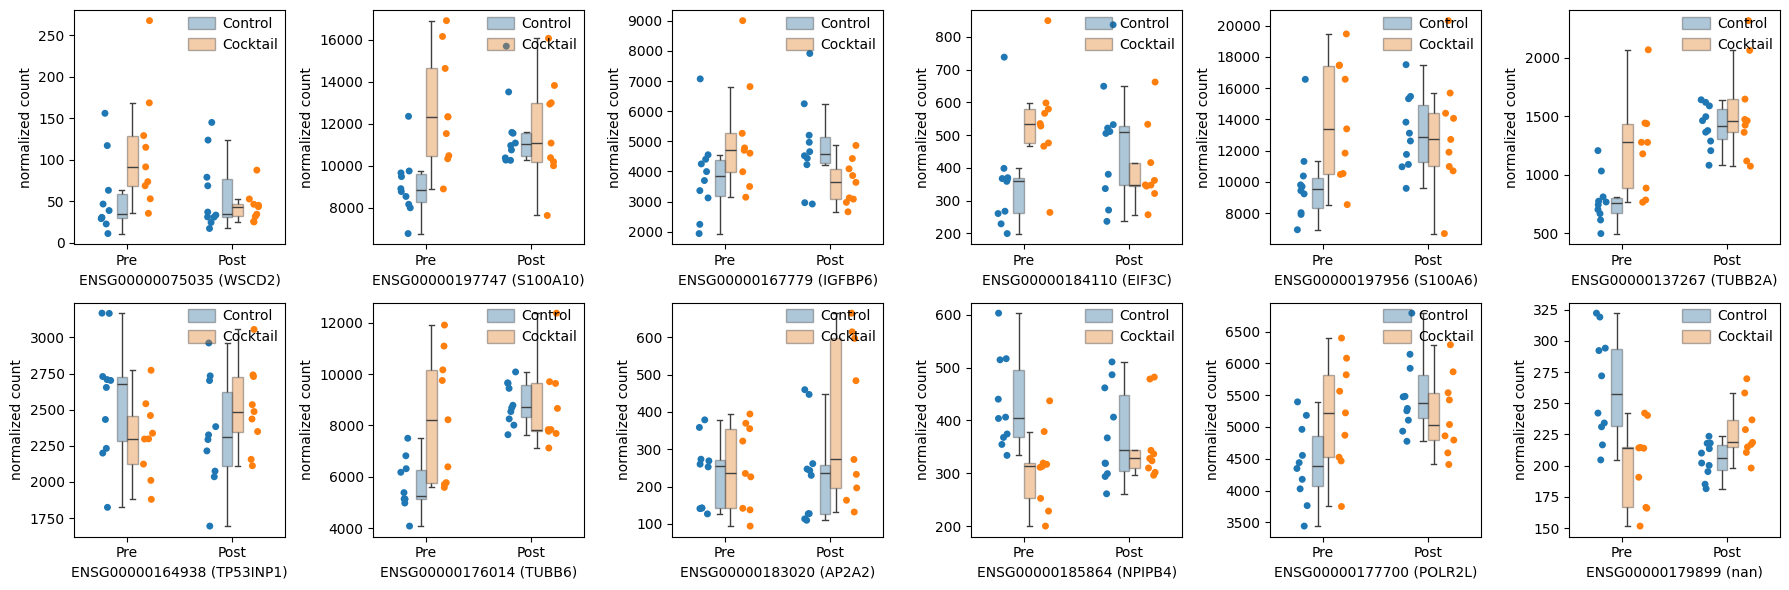

In [160]:
gene_ids = [gene_id.split(".")[0] for gene_id in """ENSG00000075035.9  ENSG00000197747.8  ENSG00000167779.8  ENSG00000184110.14 ENSG00000197956.9 
ENSG00000137267.5  ENSG00000164938.13 ENSG00000176014.12 ENSG00000183020.13 ENSG00000185864.16 
ENSG00000177700.5  ENSG00000179899.8""".split()]

genes = gene_names.set_index("initial_alias").loc[gene_ids, "name"]

titles = [f"{i} ({gene_name})" for i, gene_name in genes.items()]

draw_gene_boxplot(gene_ids, titles=titles)

## groupCocktail_Control_tmpPost GSEA

In [7]:
with open(os.path.join(work_dir, "ensembl_gene_id_list.csv"), "w") as f:
    f.write("\n".join([gene_id.split(".")[0] for gene_id in groupCocktail_Control_tmpPost.index.astype("str")]))

In [10]:
groupCocktail_Control_tmpPost["gene_id"] = groupCocktail_Control_tmpPost.index.to_series().str.split(".", expand=True).iloc[:,0]
groupCocktail_Control_tmpPost["gene_id"].isin(gene_names.initial_alias.values).all()

np.True_

In [11]:
gene_names.value_counts("initial_alias")

initial_alias
ENSG00000285994    1
ENSG00000000003    1
ENSG00000000005    1
ENSG00000000419    1
ENSG00000285977    1
                  ..
ENSG00000001084    1
ENSG00000001036    1
ENSG00000000971    1
ENSG00000000938    1
ENSG00000000460    1
Name: count, Length: 58676, dtype: int64

In [13]:
groupCocktail_Control_tmpPost["gene_name"] = gene_names.set_index("initial_alias").loc[groupCocktail_Control_tmpPost.gene_id, "name"].values
groupCocktail_Control_tmpPost

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,gene_name
ENSG00000223972.5,0.504006,0.225039,5.902148,0.038128,0.969585,NaN,ENSG00000223972,NaN
ENSG00000227232.5,84.283295,-0.024004,0.356272,-0.067375,0.946283,0.993535,ENSG00000227232,NaN
ENSG00000278267.1,14.634417,0.092786,0.405513,0.228811,0.819016,NaN,ENSG00000278267,MIR6859-1
ENSG00000243485.5,0.055123,-0.642436,5.928341,-0.108367,0.913705,NaN,ENSG00000243485,NaN
ENSG00000284332.1,0.000000,NaN,NaN,NaN,NaN,NaN,ENSG00000284332,MIR1302-2
...,...,...,...,...,...,...,...,...
ENSG00000198695.2,210370.483873,-0.067107,0.099287,-0.675885,0.499114,0.886194,ENSG00000198695,MT-ND6
ENSG00000210194.1,6.872186,0.415175,0.529952,0.783420,0.433380,NaN,ENSG00000210194,NaN
ENSG00000198727.2,867322.680673,-0.169309,0.107956,-1.568315,0.116808,0.631204,ENSG00000198727,MT-CYB
ENSG00000210195.2,0.025263,-0.352342,5.928252,-0.059434,0.952606,NaN,ENSG00000210195,NaN


In [30]:
groupCocktail_Control_tmpPost_ = groupCocktail_Control_tmpPost.drop_duplicates("gene_name", keep=False)
groupCocktail_Control_tmpPost_ = groupCocktail_Control_tmpPost_.set_index("gene_name")

data = groupCocktail_Control_tmpPost_[["stat"]].T.rename(index={"stat": "Cocktail_vs_Control"})
data = data.dropna(axis=1)

In [31]:
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
# pw_acts = pw_acts.loc[:, msk]

pw_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Cocktail_vs_Control,2.404286,12.437767,4.01901,-14.686021,-3.301327,4.269121,-1.511038,7.648546,0.324028,1.986218,0.069313,2.708177,0.394999,1.197249


In [32]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# # Filter by sign padj
# msk = (tf_padj.T < 0.05).iloc[:, 0]
# tf_acts = tf_acts.loc[:, msk]

tf_acts

,ABL1,AHR,AHRR,AIP,AIRE,AP1,APEX1,AR,ARID1A,ARID1B,...,ZNF382,ZNF384,ZNF395,ZNF410,ZNF436,ZNF699,ZNF76,ZNF804A,ZNF91,ZXDC
Cocktail_vs_Control,1.736408,0.082733,0.124625,-1.922667,-0.656641,0.61494,1.084278,2.191761,0.894961,-0.871388,...,-0.521695,-0.950551,-0.73178,1.561174,1.32718,-0.890334,0.293952,0.369937,-0.153584,0.088388


In [33]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

hm_acts

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Cocktail_vs_Control,9.350083,-0.942251,0.651103,1.765125,-1.782634,-0.907542,0.96518,3.115894,2.848057,1.7274,...,-1.116763,4.795707,-2.218975,-0.679898,1.393028,5.849578,-2.834563,3.623377,-2.306387,4.201363


In [37]:
# Run
signor_acts, signor_padj = dc.mt.ulm(data=data, net=signor)

signor_acts

,AMPK Signaling,Acute Myeloid Leukemia,Adipogenesis,Alzheimer,Autophagy,Axon guidance,B-cell activation,COVID-19 Causal Network,Cell cycle: G1/S phase transition,Cell cycle: G2/M phase transition,...,Sonic Hedgehog,T cell activation,TGF-beta Signaling,TNF-alpha Signaling,Thyroid Hormone Metabolism,Thyroid cancer,Toll like receptors,VEGF Signaling,Vitamin-K cycle,WNT Signaling
Cocktail_vs_Control,-1.27589,-2.14816,-1.549378,-0.089093,0.340039,-1.413801,-2.015947,0.204356,-0.554047,-0.401661,...,-0.630508,-1.674526,-1.46974,0.68011,-0.959236,-0.158772,-0.729839,-1.278602,1.639529,-0.142557


In [42]:
# Run
reactome_acts, reactome_padj = dc.mt.ulm(data=data, net=reactome)

reactome_acts

,REACTOMEMATURATION_OF__SARS_COV_1_NUCLEOPROTEIN,REACTOME_2_LTR_CIRCLE_FORMATION,REACTOME_ABACAVIR_ADME,REACTOME_ABACAVIR_TRANSMEMBRANE_TRANSPORT,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTERS_IN_LIPID_HOMEOSTASIS,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ABERRANT_REGULATION_OF_MITOTIC_EXIT_IN_CANCER_DUE_TO_RB1_DEFECTS,REACTOME_ABERRANT_REGULATION_OF_MITOTIC_G1_S_TRANSITION_IN_CANCER_DUE_TO_RB1_DEFECTS,REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT,...,REACTOME_WNT5A_DEPENDENT_INTERNALIZATION_OF_FZD2_FZD5_AND_ROR2,REACTOME_WNT5A_DEPENDENT_INTERNALIZATION_OF_FZD4,REACTOME_WNT_LIGAND_BIOGENESIS_AND_TRAFFICKING,REACTOME_WNT_MEDIATED_ACTIVATION_OF_DVL,REACTOME_XENOBIOTICS,REACTOME_YAP1_AND_WWTR1_TAZ_STIMULATED_GENE_EXPRESSION,REACTOME_ZBP1_DAI_MEDIATED_INDUCTION_OF_TYPE_I_IFNS,REACTOME_ZINC_EFFLUX_AND_COMPARTMENTALIZATION_BY_THE_SLC30_FAMILY,REACTOME_ZINC_INFLUX_INTO_CELLS_BY_THE_SLC39_GENE_FAMILY,REACTOME_ZINC_TRANSPORTERS
Cocktail_vs_Control,-0.327559,0.541222,-1.790559,-0.193659,6.340839,-0.512103,8.346962,1.17829,0.304865,3.430733,...,-0.112823,0.013508,0.824137,-0.354055,-0.505671,-2.50325,-1.413344,-1.100837,0.645473,-0.140411


In [46]:
# Run
kegg_acts, kegg_padj = dc.mt.ulm(data=data, net=kegg)

kegg_acts

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS,KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION,KEGG_VASCULAR_SMOOTH_MUSCLE_CONTRACTION,KEGG_VASOPRESSIN_REGULATED_WATER_REABSORPTION,KEGG_VEGF_SIGNALING_PATHWAY,KEGG_VIBRIO_CHOLERAE_INFECTION,KEGG_VIRAL_MYOCARDITIS,KEGG_WNT_SIGNALING_PATHWAY
Cocktail_vs_Control,-1.909713,-1.888048,-2.518227,0.01299,1.88376,-1.558144,-0.334894,1.566226,8.221805,4.50264,...,-3.54251,-1.135112,2.17926,3.993,-2.122139,2.297515,-0.514973,1.610541,0.229324,-1.139734


In [51]:
# Run
go_bp_acts, go_bp_padj = dc.mt.ulm(data=data, net=go_bp)

go_bp_acts

,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,GOBP_2FE_2S_CLUSTER_ASSEMBLY,GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,GOBP_4FE_4S_CLUSTER_ASSEMBLY,GOBP_5S_CLASS_RRNA_TRANSCRIPTION_BY_RNA_POLYMERASE_III,GOBP_5_PHOSPHORIBOSE_1_DIPHOSPHATE_METABOLIC_PROCESS,GOBP_7_METHYLGUANOSINE_CAP_HYPERMETHYLATION,...,GOBP_XENOBIOTIC_TRANSPORT,GOBP_XENOBIOTIC_TRANSPORT_ACROSS_BLOOD_BRAIN_BARRIER,GOBP_XENOPHAGY,GOBP_XMP_METABOLIC_PROCESS,GOBP_XYLULOSE_5_PHOSPHATE_METABOLIC_PROCESS,GOBP_ZINC_ION_IMPORT_ACROSS_PLASMA_MEMBRANE,GOBP_ZINC_ION_IMPORT_INTO_ORGANELLE,GOBP_ZINC_ION_TRANSPORT,GOBP_ZYMOGEN_ACTIVATION,GOBP_ZYMOGEN_INHIBITION
Cocktail_vs_Control,2.557227,3.035853,1.809352,0.635128,-1.536637,0.337883,2.132856,0.160917,1.082637,6.157969,...,-1.611398,-1.594854,-1.912326,3.147113,2.978765,-1.038296,-1.192326,-0.056955,3.628073,-0.636963


In [52]:
# Run
go_cc_acts, go_cc_padj = dc.mt.ulm(data=data, net=go_cc)

go_cc_acts

,GOCC_90S_PRERIBOSOME,GOCC_9PLUS0_MOTILE_CILIUM,GOCC_9PLUS0_NON_MOTILE_CILIUM,GOCC_9PLUS2_MOTILE_CILIUM,GOCC_ACETYLCHOLINE_GATED_CHANNEL_COMPLEX,GOCC_ACETYLTRANSFERASE_COMPLEX,GOCC_ACROSOMAL_MEMBRANE,GOCC_ACROSOMAL_VESICLE,GOCC_ACTIN_BASED_CELL_PROJECTION,GOCC_ACTIN_CYTOSKELETON,...,GOCC_VOLTAGE_GATED_SODIUM_CHANNEL_COMPLEX,GOCC_WASH_COMPLEX,GOCC_WEIBEL_PALADE_BODY,GOCC_WNT_SIGNALOSOME,GOCC_XY_BODY,GOCC_X_CHROMOSOME,GOCC_ZONA_PELLUCIDA_RECEPTOR_COMPLEX,GOCC_ZONULA_ADHERENS,GOCC_ZYMOGEN_GRANULE,GOCC_ZYMOGEN_GRANULE_MEMBRANE
Cocktail_vs_Control,1.367949,0.046923,0.656851,-0.244014,-0.564846,-1.754523,0.951666,0.673553,-4.705485,-3.989716,...,-1.017048,-1.266638,-1.481089,-1.045889,-1.388977,-2.266369,2.326604,-1.617404,-0.622267,-0.199522


In [53]:
# Run
go_mf_acts, go_mf_padj = dc.mt.ulm(data=data, net=go_mf)

go_mf_acts

,GOMF_11_CIS_RETINAL_BINDING,GOMF_14_3_3_PROTEIN_BINDING,GOMF_17_BETA_HYDROXYSTEROID_DEHYDROGENASE_NADPLUS_ACTIVITY,GOMF_1_4_ALPHA_OLIGOGLUCAN_PHOSPHORYLASE_ACTIVITY,GOMF_1_ACYLGLYCEROPHOSPHOCHOLINE_O_ACYLTRANSFERASE_ACTIVITY,GOMF_1_ALKYL_2_ACETYLGLYCEROPHOSPHOCHOLINE_ESTERASE_ACTIVITY,GOMF_1_PHOSPHATIDYLINOSITOL_3_KINASE_ACTIVITY,GOMF_1_PHOSPHATIDYLINOSITOL_4_PHOSPHATE_3_KINASE_ACTIVITY,GOMF_1_PHOSPHATIDYLINOSITOL_4_PHOSPHATE_5_KINASE_ACTIVITY,GOMF_1_PHOSPHATIDYLINOSITOL_BINDING,...,GOMF_WATER_CHANNEL_ACTIVITY,GOMF_WATER_TRANSMEMBRANE_TRANSPORTER_ACTIVITY,GOMF_WIDE_PORE_CHANNEL_ACTIVITY,GOMF_WNT_PROTEIN_BINDING,GOMF_WNT_RECEPTOR_ACTIVITY,GOMF_WW_DOMAIN_BINDING,GOMF_XENOBIOTIC_TRANSMEMBRANE_TRANSPORTER_ACTIVITY,GOMF_XMP_5_NUCLEOSIDASE_ACTIVITY,GOMF_ZINC_ION_BINDING,GOMF_ZINC_ION_TRANSMEMBRANE_TRANSPORTER_ACTIVITY
Cocktail_vs_Control,0.285964,-1.138312,0.026307,1.657902,-1.120563,0.30725,-1.323759,-2.137173,-0.784218,-1.73628,...,-0.108822,0.114897,0.17279,-0.443624,-1.350652,-1.422596,-1.250796,-0.638601,-2.613368,-0.254171


### Reactome

(1, 336)


/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


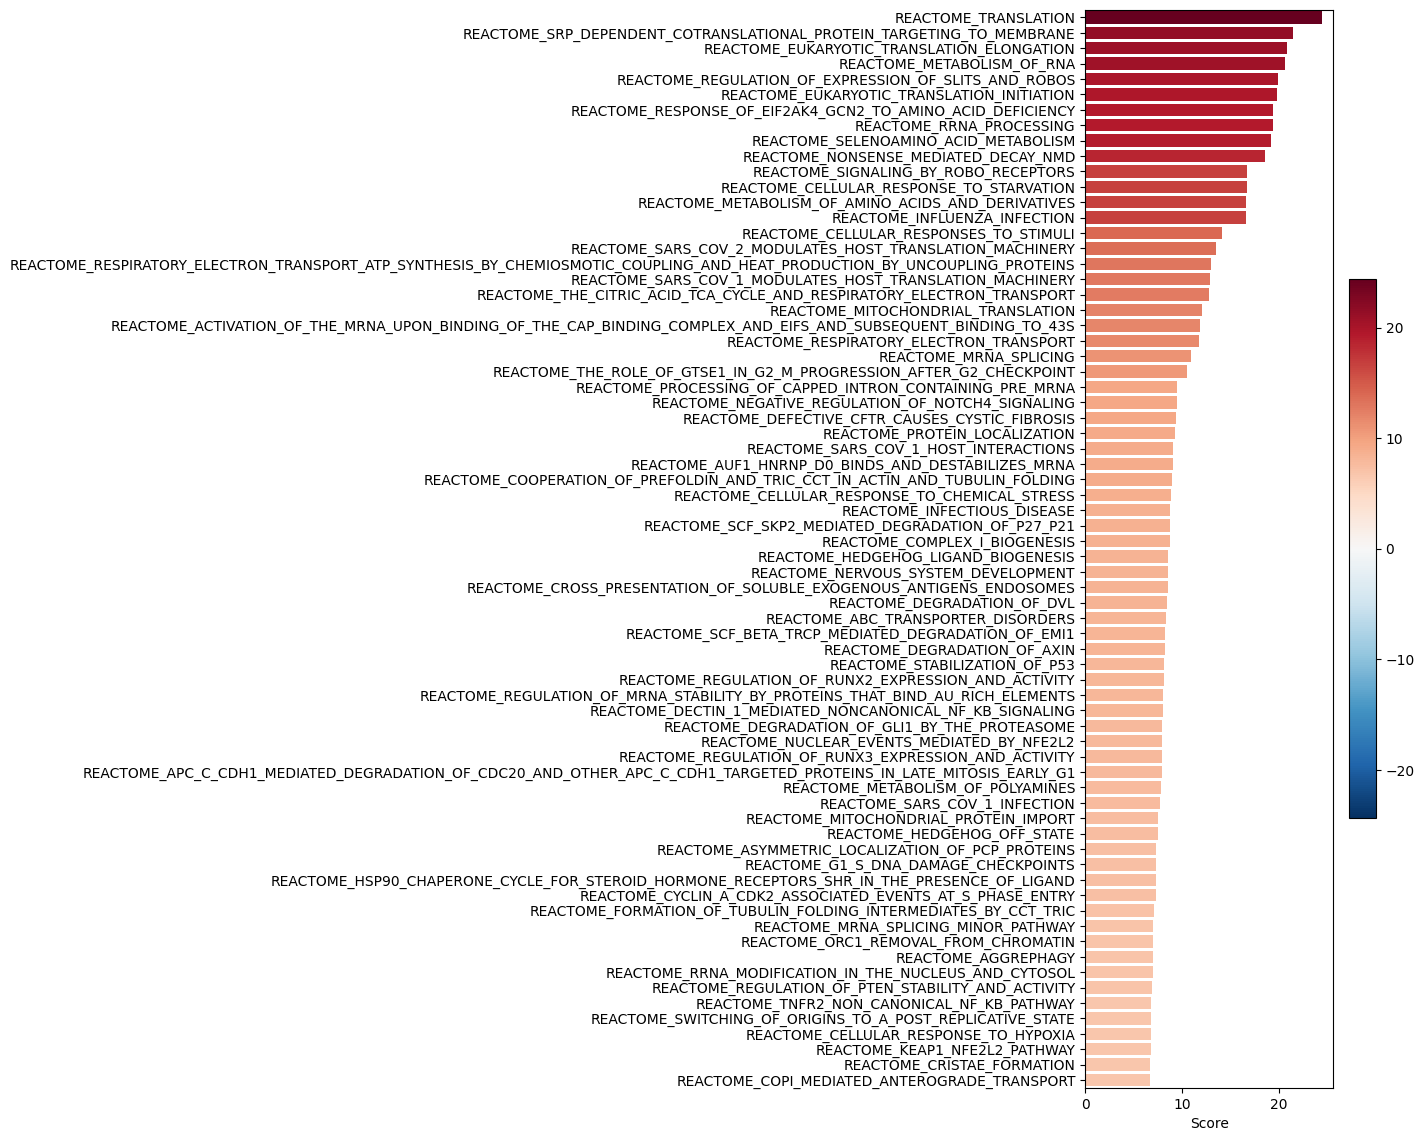

In [54]:
a = 0.05
name = "Cocktail_vs_Control"
masked = reactome_acts.loc[[name,], (reactome_padj.loc[name,:] < a)]
print(masked.shape)
dc.pl.barplot(data=masked, name=name, top=70, figsize=(4, 14))

leading edge: ['MRPL24' 'EIF3C' 'GADD45GIP1' 'RPLP1' 'RPL35']


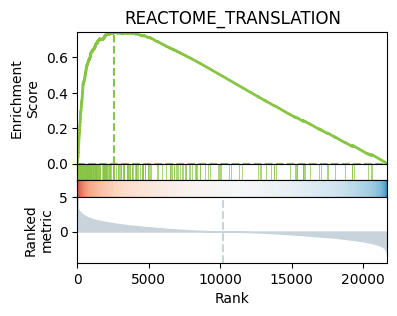

In [84]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=reactome,
    name="REACTOME_TRANSLATION",
)
print("leading edge:", le[:5])

### KEGG

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


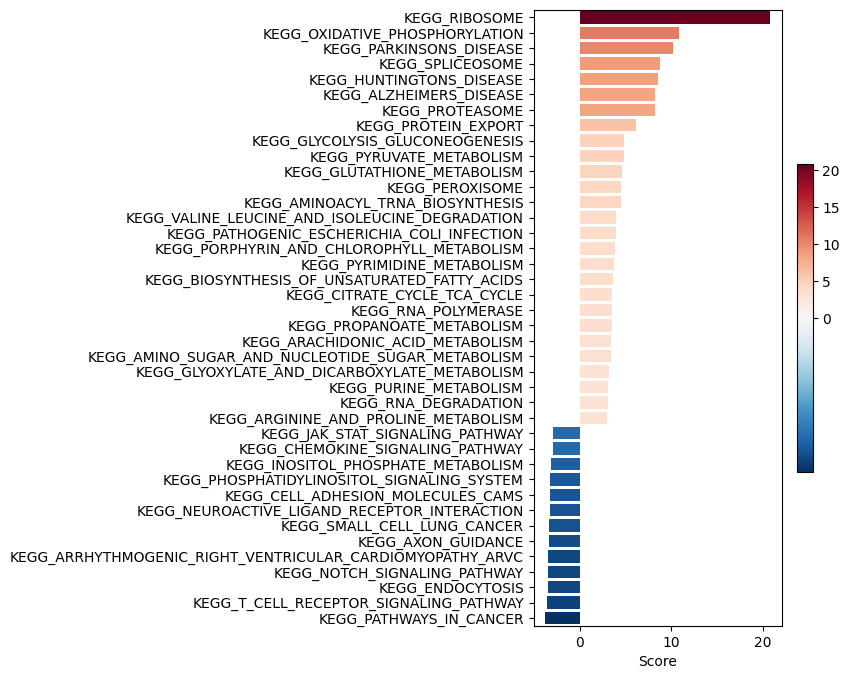

In [55]:
a = 0.05
name = "Cocktail_vs_Control"
masked = kegg_acts.loc[[name,], (kegg_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=40, figsize=(4, 8))

leading edge: ['RPLP1' 'RPL35' 'RPS11' 'RPS12' 'RPL38']


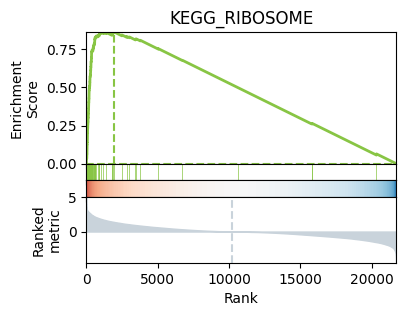

In [171]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=kegg,
    name="KEGG_RIBOSOME",
)
print("leading edge:", le[:5])

In [163]:
# kegg_ribosome = kegg.loc[kegg.source == "KEGG_RIBOSOME", "target"].unique()

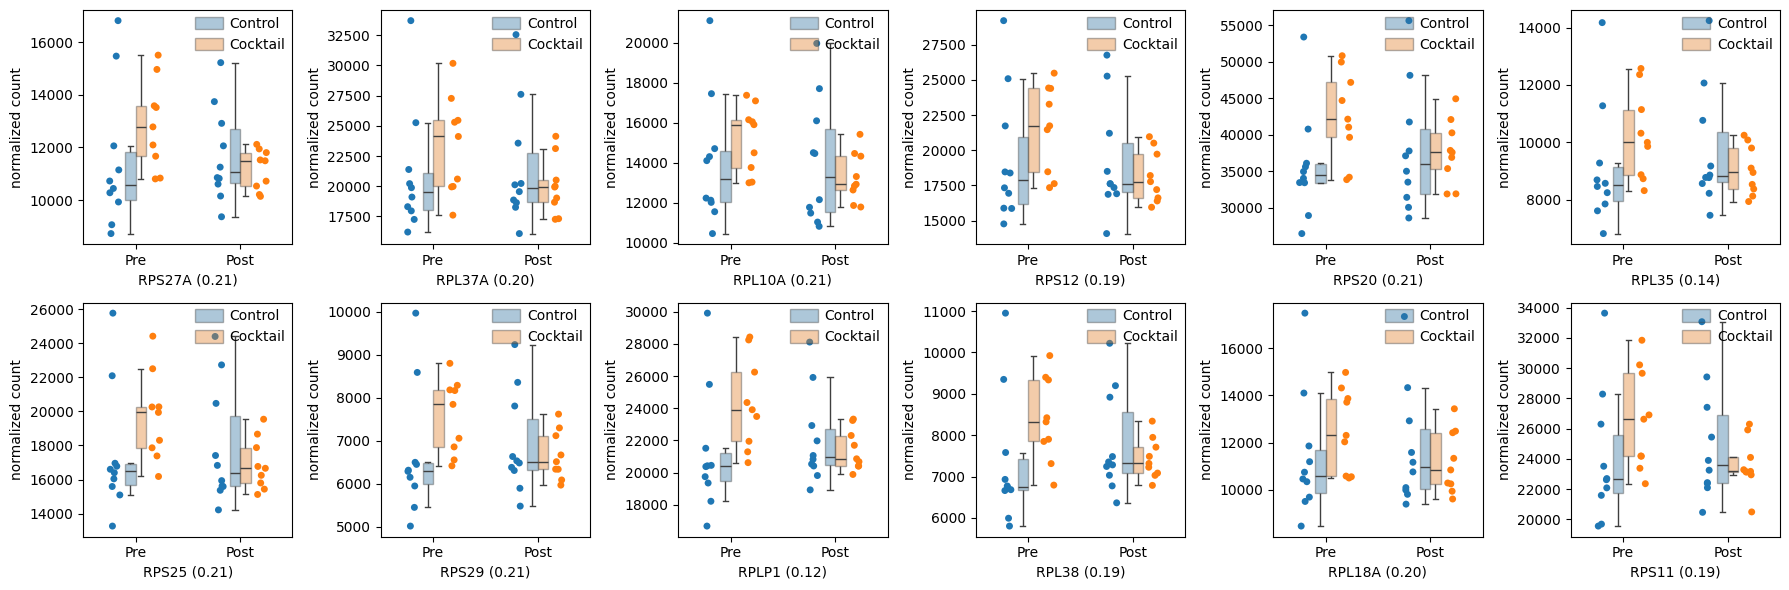

In [182]:

n_top = 12
genes = gene_names.loc[gene_names.name.isin(le[:n_top]), :]

gene_ids = genes.initial_alias
gene_pvals = groupCocktail_Control_tmpPost_.loc[genes.name, "padj"].astype(str).str[:4].values
titles = genes.name + " (" + gene_pvals + ")"

draw_gene_boxplot(gene_ids.values, titles=titles.values)

leading edge: ['COX7A1' 'ATP5F1E' 'UQCRQ' 'NDUFB7' 'NDUFS5']


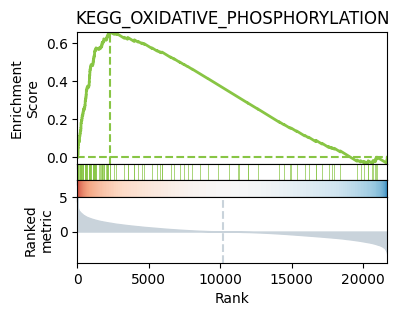

In [185]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=kegg,
    name="KEGG_OXIDATIVE_PHOSPHORYLATION",
)
print("leading edge:", le[:5])

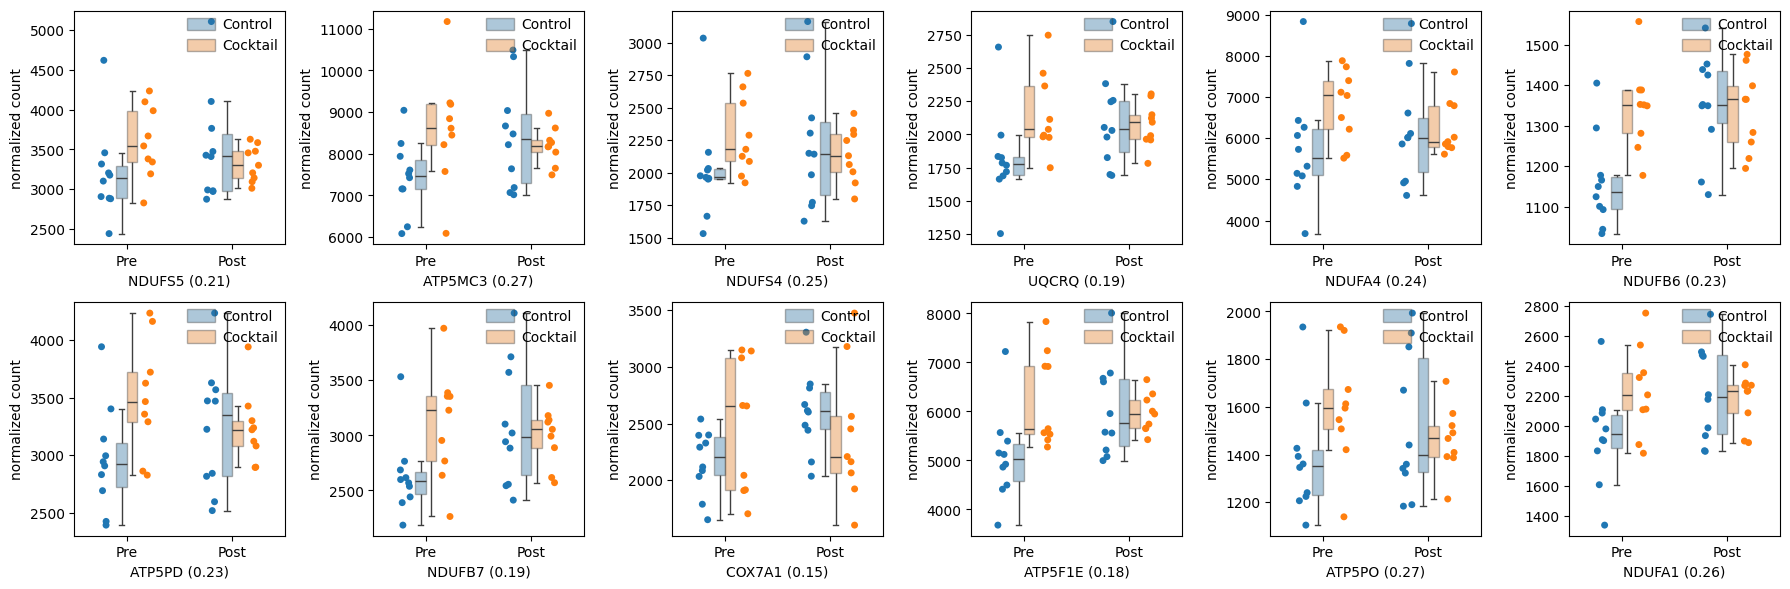

In [186]:

n_top = 12
genes = gene_names.loc[gene_names.name.isin(le[:n_top]), :]

gene_ids = genes.initial_alias
gene_pvals = groupCocktail_Control_tmpPost_.loc[genes.name, "padj"].astype(str).str[:4].values
titles = genes.name + " (" + gene_pvals + ")"

draw_gene_boxplot(gene_ids.values, titles=titles.values)

### GO

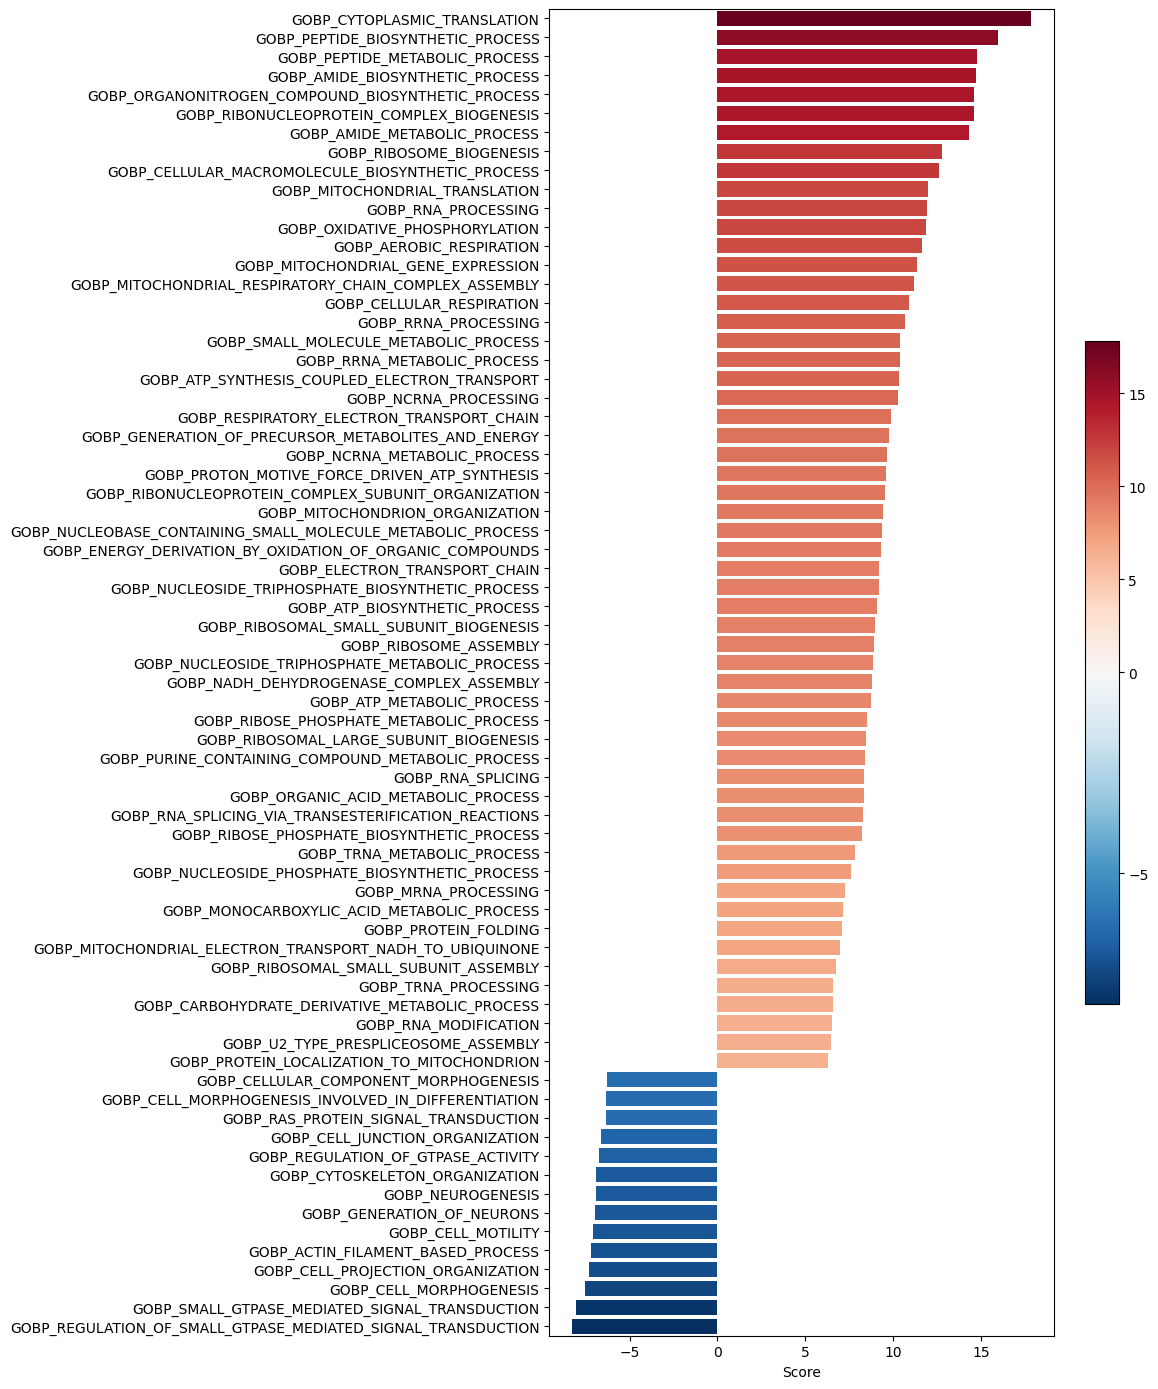

In [56]:
a = 0.05
name = "Cocktail_vs_Control"
masked = go_bp_acts.loc[[name,], (go_bp_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=70, figsize=(12, 14))

leading edge: ['EIF3C' 'RPLP1' 'RPL35' 'RPS11' 'RPS12']


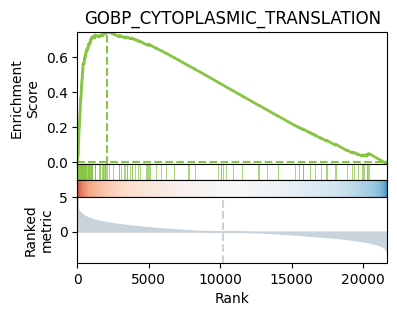

In [81]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=go_bp,
    name="GOBP_CYTOPLASMIC_TRANSLATION",
)
print("leading edge:", le[:5])

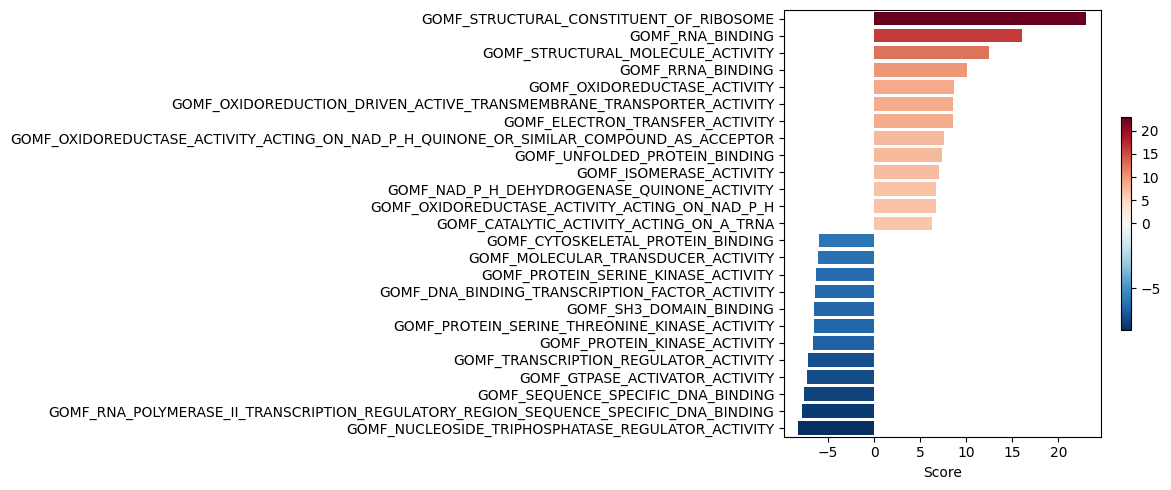

In [57]:
a = 0.05
name = "Cocktail_vs_Control"
masked = go_mf_acts.loc[[name,], (go_mf_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(12, 5))

leading edge: ['MRPL24' 'RPLP1' 'RPL35' 'RPS11' 'MRPL1']


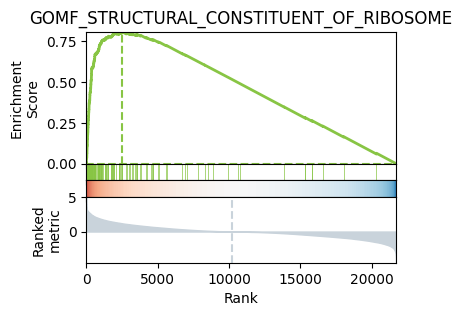

In [80]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=go_mf,
    name="GOMF_STRUCTURAL_CONSTITUENT_OF_RIBOSOME",
)
print("leading edge:", le[:5])

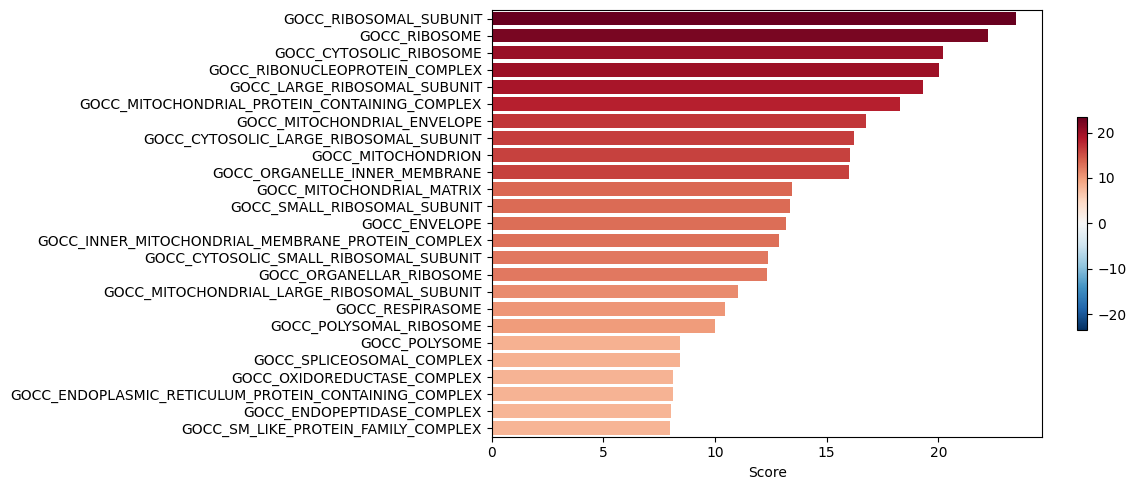

In [58]:
a = 0.05
name = "Cocktail_vs_Control"
masked = go_cc_acts.loc[[name,], (go_cc_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(12, 5))

leading edge: ['MRPL24' 'GADD45GIP1' 'RPLP1' 'RPL35' 'RPS11']


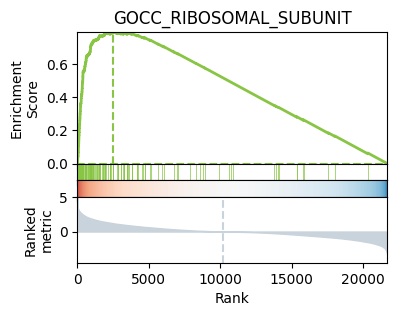

In [78]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=go_cc,
    name="GOCC_RIBOSOMAL_SUBUNIT",
)
print("leading edge:", le[:5])

leading edge: ['MRPL24' 'GADD45GIP1' 'RPLP1' 'RPL35' 'RPS11']


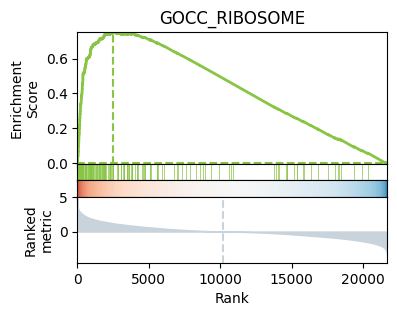

In [79]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=go_cc,
    name="GOCC_RIBOSOME",
)
print("leading edge:", le[:5])

In [59]:
a = 0.05
name = "Cocktail_vs_Control"
masked = immunesigdb_acts.loc[[name,], (immunesigdb_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(10, 5))

NameError: name 'immunesigdb_acts' is not defined

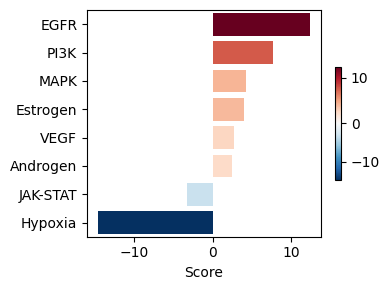

In [60]:
a = 0.05
name = "Cocktail_vs_Control"
masked = pw_acts.loc[[name,], (pw_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(4, 3))

(+) leading edge: ['MADD' 'CDK19' 'MYLIP' 'TBC1D8B' 'PRDM1']
(-) leading edge: ['POLR2L' 'DYNLL1' 'MRPL24' 'GPATCH4' 'SLIRP']


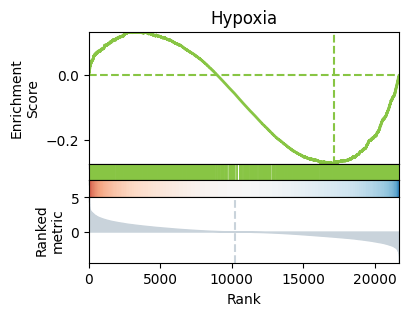

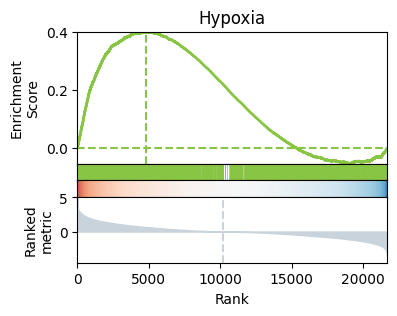

In [69]:
_, pos_le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name="Hypoxia",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=progeny[progeny["weight"] < 0],
    name="Hypoxia",
)
print("(-) leading edge:", neg_le[:5])

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


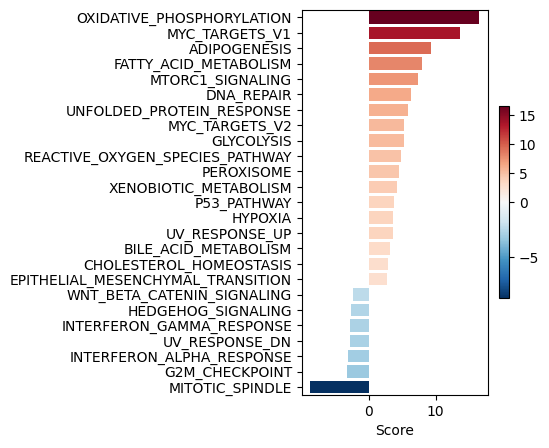

In [61]:
a = 0.05
name = "Cocktail_vs_Control"
masked = hm_acts.loc[[name,], (hm_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(3, 5))

leading edge: ['ATP5F1E' 'UQCRQ' 'NDUFB7' 'GPX4' 'TIMM8B']


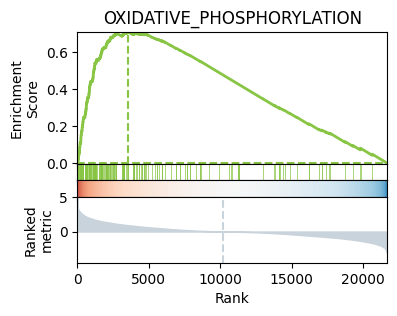

In [72]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=hallmark,
    name="OXIDATIVE_PHOSPHORYLATION",
)
print("leading edge:", le[:5])

leading edge: ['NCK1' 'CD2AP' 'CEP57' 'PCNT' 'TUBGCP3']


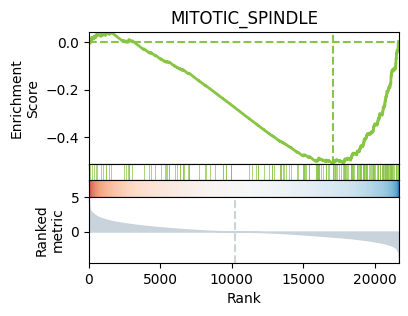

In [73]:
_, le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=hallmark,
    name="MITOTIC_SPINDLE",
)
print("leading edge:", le[:5])

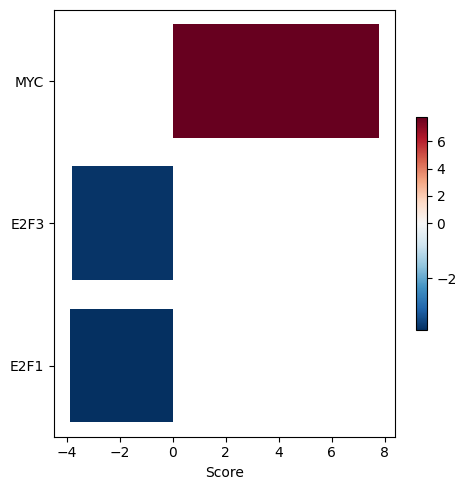

In [62]:
a = 0.05
name = "Cocktail_vs_Control"
masked = tf_acts.loc[[name,], (tf_padj.loc[name,:] < a)]
dc.pl.barplot(data=masked, name=name, top=25, figsize=(5, 5))

(+) leading edge: ['EIF3C' 'RPLP1' 'RPL35' 'NME1' 'LMNA']
(-) leading edge: ['TP53INP1' 'IGF2' 'CPD' 'HECTD4' 'NCAM1']


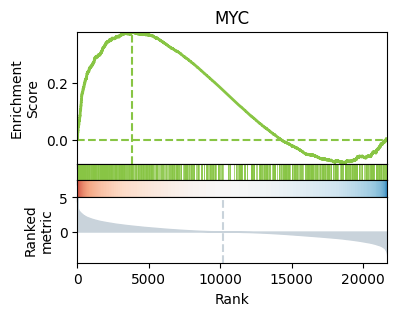

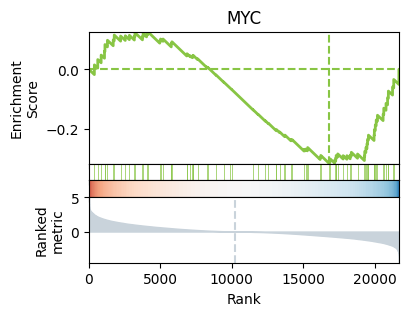

In [76]:
_, pos_le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=collectri[collectri["weight"] > 0],
    name="MYC",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    groupCocktail_Control_tmpPost_,
    stat="stat",
    net=collectri[collectri["weight"] < 0],
    name="MYC",
)
print("(-) leading edge:", neg_le[:5])